In [30]:
import pandas as pd
import glob
import re
import os

def get_final_task_2_results():
    # 1. Path setup for your 'Data' folder
    path = os.path.join('Data', '*.txt')
    files = glob.glob(path)
    
    if not files:
        print("Error: No files found in 'Data/' folder. Make sure the folder is named correctly.")
        return

    all_data = []
    for f in files:
        try:
            # Extract Gene Name from filename (e.g., Ah3_data_file.txt -> Ah3)
            gene_name = re.search(r'([A-Za-z0-9]+)_data', os.path.basename(f)).group(1)
            
            # Load the data file
            df = pd.read_csv(f, sep='\t')

            # Calculate average mRNA expression for WT and Mutant
            wt_mean = df[['mRNA.Expression.WT.Rep1', 'mRNA.Expression.WT.Rep2', 'mRNA.Expression.WT.Rep3']].mean(axis=1).iloc[0]
            mut_mean = df[['mRNA.Expression.Mut.Rep1', 'mRNA.Expression.Mut.Rep2', 'mRNA.Expression.Mut.Rep3']].mean(axis=1).iloc[0]
            
            # Determine Mutation Class (matches your friend's 'del', 'sub', 'ins' style)
            wt_seq, mut_seq = str(df['WildType.Sequence'].iloc[0]), str(df['Mutant.Sequence'].iloc[0])
            if len(mut_seq) < len(wt_seq):
                m_class = 'del'
            elif len(mut_seq) > len(wt_seq):
                m_class = 'ins'
            else:
                m_class = 'sub'

            # Store the calculation results
            all_data.append({
                'Gene': gene_name,
                'Mutation_Class': m_class,
                'Expression_Change': abs(mut_mean - wt_mean)
            })
        except Exception:
            continue

    # 2. Sort by change and grab the top 5
    master_table = pd.DataFrame(all_data)
    top_5 = master_table.sort_values(by='Expression_Change', ascending=False).head(5)
    
    print("\n--- TASK 2: TOP 5 GENES FOR VALIDATION ---")
    print(top_5[['Gene', 'Mutation_Class', 'Expression_Change']].to_string(index=False))

# Run the script
get_final_task_2_results()


--- TASK 2: TOP 5 GENES FOR VALIDATION ---
   Gene Mutation_Class  Expression_Change
 Ist9a2            del        5010.362690
Anap7c1            sub          49.528187
Dsgt9a1            ins           3.768895
 Jok4a3            sub           1.577621
  Avon4            ins           1.445566


/var/folders/3f/3c83z30129d907w_1yzhrs_h0000gn/T/ipykernel_25734/4272278594.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Mutation_Class', y='Expression_Change', data=master_df, palette='Set2')


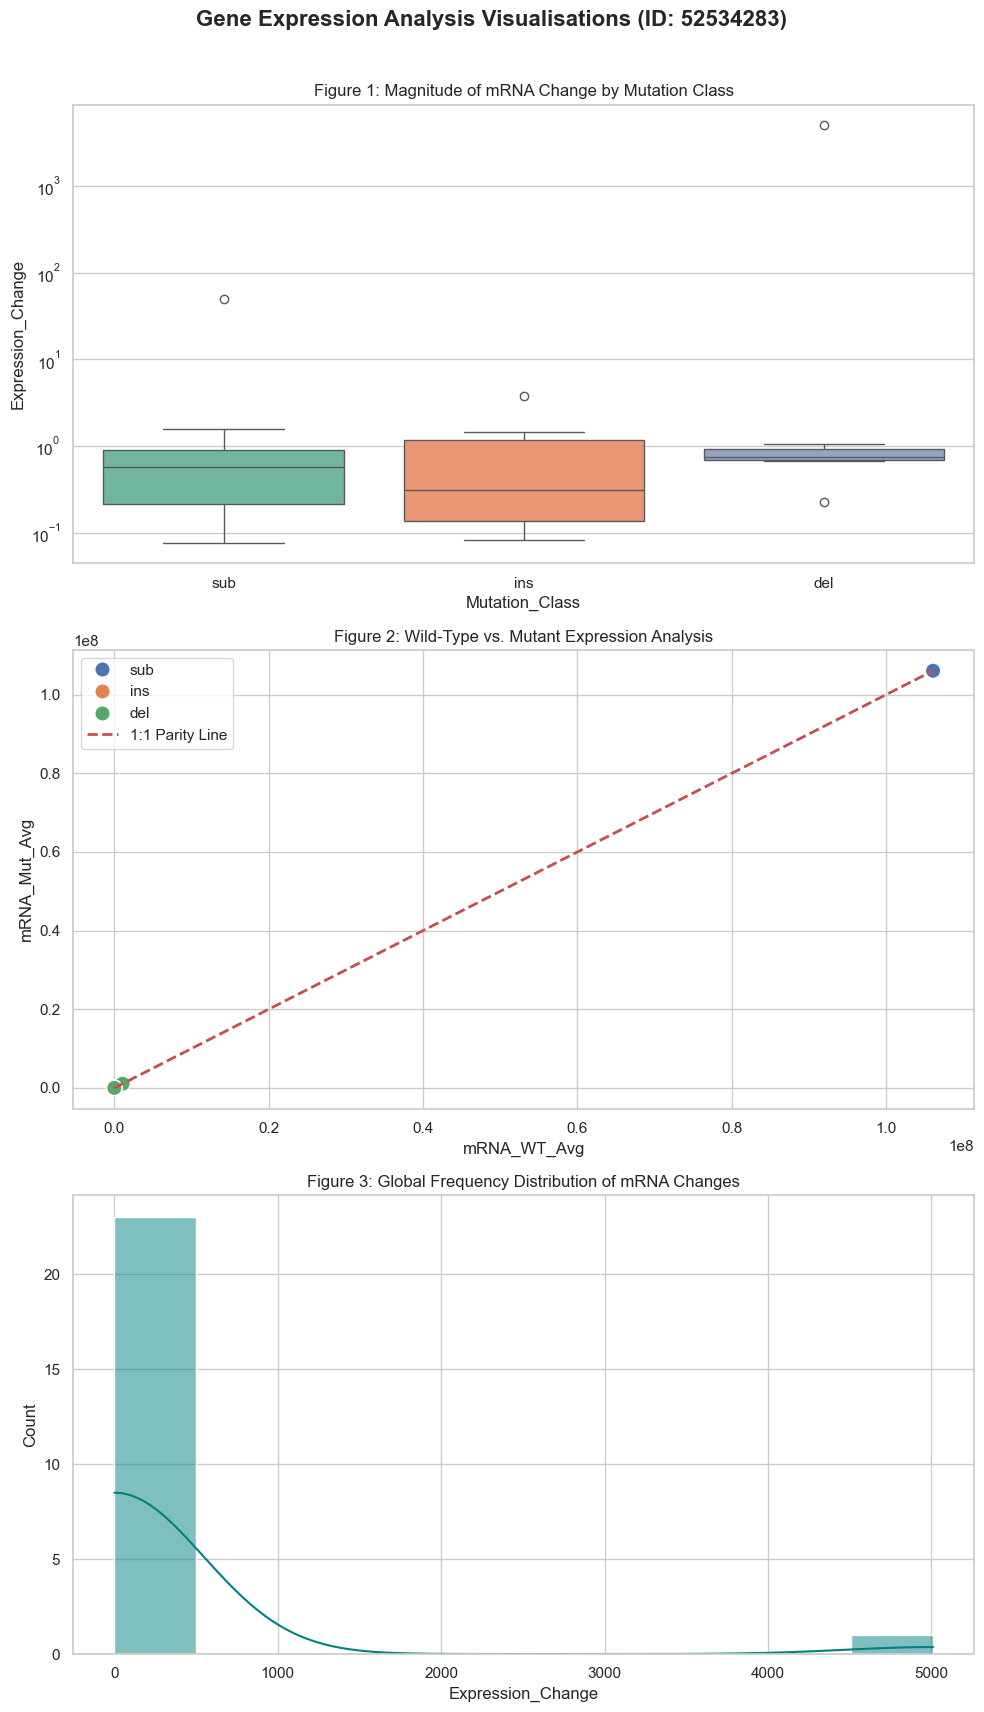

In [35]:
import pandas as pd
import glob
import re
import os
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

def generate_full_report_visuals():
    path = os.path.join('Data', '*.txt')
    files = glob.glob(path)
    
    if not files:
        print("Error: No files found in 'Data/' folder.")
        return

    processed_data = []
    for f in files:
        try:
            gene_name = re.search(r'([A-Za-z0-9]+)_data', os.path.basename(f)).group(1)
            df = pd.read_csv(f, sep='\t')
            
            wt_avg = df[['mRNA.Expression.WT.Rep1', 'mRNA.Expression.WT.Rep2', 'mRNA.Expression.WT.Rep3']].mean(axis=1).iloc[0]
            mut_avg = df[['mRNA.Expression.Mut.Rep1', 'mRNA.Expression.Mut.Rep2', 'mRNA.Expression.Mut.Rep3']].mean(axis=1).iloc[0]
            
            wt_seq, mut_seq = str(df['WildType.Sequence'].iloc[0]), str(df['Mutant.Sequence'].iloc[0])
            if len(mut_seq) < len(wt_seq): m_class = 'del'
            elif len(mut_seq) > len(wt_seq): m_class = 'ins'
            else: m_class = 'sub'

            processed_data.append({
                'Gene': gene_name,
                'Mutation_Class': m_class,
                'mRNA_WT_Avg': wt_avg,
                'mRNA_Mut_Avg': mut_avg,
                'Expression_Change': abs(mut_avg - wt_avg)
            })
        except: continue

    master_df = pd.DataFrame(processed_data)

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 1, figsize=(10, 18))
    fig.suptitle('Gene Expression Analysis Visualisations (ID: 52534283)', fontsize=16, fontweight='bold')

    sns.boxplot(ax=axes[0], x='Mutation_Class', y='Expression_Change', data=master_df, palette='Set2')
    axes[0].set_yscale('log')
    axes[0].set_title('Figure 1: Magnitude of mRNA Change by Mutation Class')

    sns.scatterplot(ax=axes[1], x='mRNA_WT_Avg', y='mRNA_Mut_Avg', hue='Mutation_Class', data=master_df, s=120)
    max_val = max(master_df['mRNA_WT_Avg'].max(), master_df['mRNA_Mut_Avg'].max())
    axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2, label='1:1 Parity Line')
    axes[1].set_title('Figure 2: Wild-Type vs. Mutant Expression Analysis')
    axes[1].legend()

    sns.histplot(ax=axes[2], data=master_df, x='Expression_Change', kde=True, color='teal')
    axes[2].set_title('Figure 3: Global Frequency Distribution of mRNA Changes')

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

generate_full_report_visuals()